# Placement POC — sensor sets with quantified dependence, per district partition

The upstream step attributed districts several ways. This notebook takes each partition,
sweeps *which district drifts*, measures what every gauge is reading, and emits the
`(district attribution, sensor placement)` tuples the federated step consumes.

Order: one case end to end with its sanity checks → the full sweep → summary and the
interactive views → the selected sets checked against demand and against the map.

## 0. Setup

In [1]:
%matplotlib inline
import sys, warnings, pathlib, json
import numpy as np, pandas as pd, matplotlib.pyplot as plt


warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 220, "display.max_columns", 80, "display.max_rows", 250)

from pathlib import Path
HERE = pathlib.Path.cwd()
ROOT = next(p for p in [HERE, *HERE.parents] if (p / "conf" / "base").exists())
# for p in (HERE, ROOT / "..\\..\\..\\src", ROOT):
#     if str(p) not in sys.path:
#         sys.path.insert(0, str(p))
sys.path.insert(0, str(Path('..\\..\\..\\src').resolve()))

import bundles as bd
import district_sweep as ds
import placement as pl
import placement_figures as F
import placement_browsers as B
import signal_probe as sp
import mixture_probe as mp

INPUT = next(p for p in (HERE.parent / "input", HERE / "input", ROOT / "input")
             if p.exists())
STORE  = ROOT / "data" / "09_experiments" / "placement"
WORLDS = STORE / "worlds"
STORE.mkdir(parents=True, exist_ok=True)
print(ROOT, "|", INPUT)

c:\Users\arthu\USPy\10_Mestrado\fedWater | c:\Users\arthu\USPy\10_Mestrado\fedWater\notebooks\0_prospection\input


## 1. Partitions → bundles

Each partition becomes its own self-describing network bundle under `data/01_raw/`, named
with a content hash of the partition itself. That is what keeps the world cache honest:
`network` is already part of `WorldCfg.identity()`, so two partitions address two worlds
and editing a partition orphans its stale worlds instead of silently reusing them.

`coverage` below is the share of a district reachable from its seed without leaving the
district. Below 1.0 the diffusion front cannot convert the whole district and the settled
state genuinely depends on the seed — read those cells as partial conversions.
`eccentricity` is the hop count the front must travel, and it is what sizes the horizon.

In [ ]:
BUNDLES = bd.prepare(ROOT, INPUT, methods=bd.PIPELINE_METHODS, base_network="dtown")
display(pd.DataFrame([b.summary() for b in BUNDLES]))
display(pd.concat([b.seeds.assign(config=b.config_id) for b in BUNDLES],
                  ignore_index=True))

materialising bundles from c:\Users\arthu\USPy\10_Mestrado\fedWater\notebooks\0_prospection\input
  fast_greedy__65c3cb80        -> dtown__fast_greedy__65c3cb80  k=5 sizes=104/95/88/63/49  min coverage 1.00  max ecc 17
  girvan_newman__3ad4da44      -> dtown__girvan_newman__3ad4da44  k=5 sizes=104/102/81/60/52  min coverage 1.00  max ecc 20
  spectral__01d6bf55           -> dtown__spectral__01d6bf55  k=5 sizes=152/96/54/52/45  min coverage 1.00  max ecc 17


,config_id,method,network,k,sizes,min_coverage,max_eccentricity,districts_without_storage
0,fast_greedy__65c3cb80,fast_greedy,dtown__fast_greedy__65c3cb80,5,104/95/88/63/49,1.0,17,0
1,girvan_newman__3ad4da44,girvan_newman,dtown__girvan_newman__3ad4da44,5,104/102/81/60/52,1.0,20,0
2,spectral__01d6bf55,spectral,dtown__spectral__01d6bf55,5,152/96/54/52/45,1.0,17,0


,district,seed_node,n_nodes,components,coverage,eccentricity,seed_base_demand,config
0,District_A,J87,104,1,1.0,17,1.8767,fast_greedy__65c3cb80
1,District_B,J234,95,1,1.0,16,0.0450,fast_greedy__65c3cb80
2,District_C,J1056,88,1,1.0,10,1.6904,fast_greedy__65c3cb80
3,District_D,J238,63,1,1.0,13,0.4694,fast_greedy__65c3cb80
4,District_E,J192,49,1,1.0,8,1.8808,fast_greedy__65c3cb80
5,District_A,J168,104,1,1.0,20,1.7407,girvan_newman__3ad4da44
6,District_B,J87,102,1,1.0,17,1.8767,girvan_newman__3ad4da44
7,District_C,J177,81,1,1.0,11,1.2380,girvan_newman__3ad4da44
8,District_D,J492,60,1,1.0,9,2.1899,girvan_newman__3ad4da44
9,District_E,J212,52,1,1.0,8,0.9100,girvan_newman__3ad4da44


### Horizon

The front width is derived from the largest district rather than fixed. With one constant,
a partition whose districts are uneven converts the small ones in two months and the large
one in thirty — and at a fixed horizon the large cell then has no settled tail at all and
`settled_window` raises. This is a *width* change to the diffusion front, which the drift
engine already parameterises; the mechanism is untouched.

`beta` is a hyperparameter now, not an axis. The consequence, stated where it will be
read: with one operating point there is no linearity check, so every dependence number
below is an operating-point statement and cannot be quoted at another beta.

In [3]:
BETA = 0.35
PLAN = ds.plan(BUNDLES, beta=BETA, anchor_scale=0.25)
CFG  = PLAN.cfg
print(f"\ngrid: {len(BUNDLES)} configurations x {len(BUNDLES[0].districts)} drift "
      f"districts = {len(BUNDLES) * len(BUNDLES[0].districts)} worlds")

horizon plan: n_months=32 x 14d | warmup 2 | front 8 nodes/month -> converts 152 nodes in ~20 months (eccentricity floor 20)

grid: 3 configurations x 5 drift districts = 15 worlds


## 2. One case, end to end

Everything that can go wrong quietly goes wrong here first. Pick one partition and solve
its K worlds before committing to the grid.

In [4]:
B0 = BUNDLES[1]
R0 = ds.run_config(B0, CFG, ROOT, WORLDS, null_factor=ds.NULL_FACTOR,
                   core_purity=ds.CORE_PURITY)
display(R0.cells[["drift_district", "status", "source", "d_demand_%",
                  "shape_shift", "gap_flow", "resp_flow_top", "seconds"]])
print(R0.status, "|", R0.error or "-")


=== girvan_newman__3ad4da44 (girvan_newman) -- 5 worlds ===
  [1/5] dtown__girvan_newman__3ad4da44/District_A/beta=0.35  cache  dDemand  +119.2%  shift 0.73  flow gap 1.01  resp 1.00  2s  | eta 0 min
  [2/5] dtown__girvan_newman__3ad4da44/District_B/beta=0.35  cache  dDemand  +116.7%  shift 0.73  flow gap 1.01  resp 1.00  1s  | eta 0 min
  [3/5] dtown__girvan_newman__3ad4da44/District_C/beta=0.35  cache  dDemand  +117.5%  shift 0.72  flow gap 0.98  resp 1.00  1s  | eta 0 min
  [4/5] dtown__girvan_newman__3ad4da44/District_D/beta=0.35  cache  dDemand  +116.8%  shift 0.72  flow gap 1.00  resp 1.00  1s  | eta 0 min
  [5/5] dtown__girvan_newman__3ad4da44/District_E/beta=0.35  cache  dDemand  +116.6%  shift 0.73  flow gap 1.00  resp 1.00  1s  | eta 0 min

5/5 cells ok in 0.1 min -> c:\Users\arthu\USPy\10_Mestrado\fedWater\data\09_experiments\placement\worlds\girvan_newman__3ad4da44
  District_A: settled from month 20
  District_B: settled from month 18
  District_C: settled from month 14
 

,drift_district,status,source,d_demand_%,shape_shift,gap_flow,resp_flow_top,seconds
0,District_A,ok,cache,119.204,0.731,1.011139,0.999904,2.5
1,District_B,ok,cache,116.731,0.726,1.010774,0.999077,1.1
2,District_C,ok,cache,117.521,0.725,0.980264,0.999266,1.1
3,District_D,ok,cache,116.783,0.722,1.001453,0.999696,1.1
4,District_E,ok,cache,116.632,0.726,0.999369,0.999490,1.1


ok | -


### 2a. Did the drift land where it was aimed?

The one assumption this refactor could not verify from the code alone. Each bundle writes
its own `drift_seed_nodes`, but `build_drift_schedule` reads the profile only as a
*fallback* behind `scenario.drift.seed_node`, and the precedence lives upstream. If the
seed resolved to a node outside its target district, the schedule would seed the drift in
the wrong place — silently.

`in_target` must be 1.00 everywhere. `coverage` is the share of the target district the
front actually converted; below 1.0 the mixture is measuring a partial conversion.

In [5]:
rows = []
for d, P in R0.probes.items():
    sch = P.schedule
    tgt = set(P.districts[d])
    seeded = set(sch["node"].astype(str))
    first = sch.loc[sch["drift_month"] == sch["drift_month"].min(), "node"].astype(str)
    rows.append({"drift_district": d, "n_scheduled": len(sch),
                 "in_target": round(len(seeded & tgt) / max(len(seeded), 1), 3),
                 "coverage": round(len(seeded & tgt) / len(tgt), 3),
                 "seed_node": list(first)[0],
                 "seed_in_target": list(first)[0] in tgt,
                 "first_month": int(sch["drift_month"].min()),
                 "last_month": int(sch["drift_month"].max())})
SEEDCHK = pd.DataFrame(rows)
display(SEEDCHK)
assert (SEEDCHK["in_target"] == 1.0).all(), "drift scheduled outside its target district"
assert SEEDCHK["seed_in_target"].all(), "seed node is not in the district it seeds"
print("seed resolution ok")

,drift_district,n_scheduled,in_target,coverage,seed_node,seed_in_target,first_month,last_month
0,District_A,104,1.0,1.0,J168,True,2,22
1,District_B,102,1.0,1.0,J87,True,2,20
2,District_C,81,1.0,1.0,J177,True,2,14
3,District_D,60,1.0,1.0,J492,True,2,11
4,District_E,52,1.0,1.0,J212,True,2,11


seed resolution ok


### 2b. Settling

`final` cannot start at `last_switch + ramp`: the profile is still moving there. The
threshold is self-calibrating — the reproducibility ceiling is measured from the reference
months, and "settled" means within a slack of it, where the slack is at least twice the
spread of those months. A fixed 0.99 would report "never settled" on any world noisy
enough to be realistic.

,drift_district,n_months,last_switch,settle_month,settled_from,settled_months,ok,need_n_months
0,District_A,32,22,19,20,12,True,23
1,District_B,32,20,17,18,14,True,21
2,District_C,32,14,13,14,18,True,17
3,District_D,32,11,10,11,21,True,14
4,District_E,32,11,10,11,21,True,14


,district,drifted,settle_month,ceiling,threshold,r_min,r_at_first_final,drift_district
0,District_A,True,19,1.0000,0.9900,0.2681,0.9999,District_A
6,District_B,True,17,1.0000,0.9900,0.2719,0.9999,District_B
12,District_C,True,13,0.9999,0.9899,0.2723,1.0000,District_C
18,District_D,True,10,1.0000,0.9900,0.2766,0.9998,District_D
24,District_E,True,10,0.9999,0.9899,0.2727,0.9999,District_E


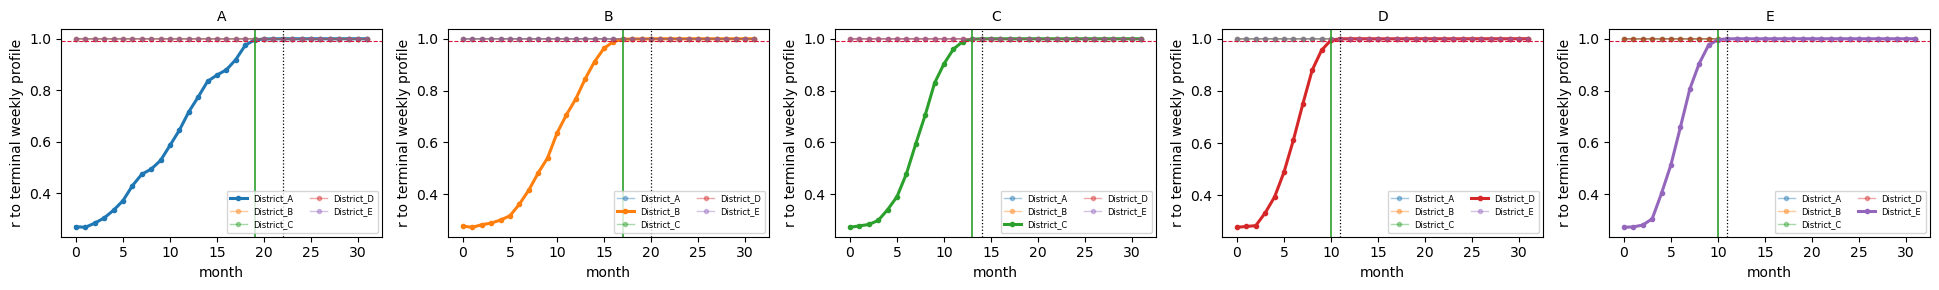

In [6]:
display(R0.horizon)
display(R0.settle[R0.settle["drifted"]])

fig, axes = plt.subplots(1, len(R0.probes), figsize=(3.9 * len(R0.probes), 3.0),
                         squeeze=False)
F.settle_panel(axes[0], R0.probes)
plt.tight_layout(); plt.show()

### 2c. Is the mixture informative, or is the threshold doing the work?

`n_live<=1_%` first. If nearly every gauge cleared the gate for exactly one district the
shares are one-hot by construction and say nothing about coupling — a statement about the
threshold, not the network. The sensitivity table is the check: a tier count that moves a
lot between `null_factor` 1 and 3 is a threshold result. `purity_histogram` shows where
the mass actually sits; mass in the middle is the population that can support a quantified
dependence statement at all.

In [7]:
display(mp.mixture_diagnostics(R0.base))
display(mp.tier_sensitivity(R0.base, factors=ds.NULL_FACTORS))
display(mp.purity_histogram(R0.base))
display(R0.stability.describe().round(3))

,kind,n,unusable_%,n_live<=1_%,n_live_mean,purity_median,snr_median,neg_mass_%
0,flow,459,11.329,49.020,2.453,1.000,11.542,39.651
1,pressure,348,2.011,27.011,3.187,0.949,4.408,38.506


,null_factor,core_purity,kind,core,transition,foreign,unusable,n_live_mean
0,1.0,0.85,flow,297,61,54,47,3.83
1,1.0,0.85,pressure,181,136,24,7,4.84
2,1.5,0.85,flow,304,53,50,52,2.45
3,1.5,0.85,pressure,181,136,24,7,3.19
4,3.0,0.85,flow,299,27,37,96,1.24
5,3.0,0.85,pressure,167,89,53,39,1.99


,kind,bin,n,share
0,flow,"[0.0, 0.15)",50,0.123
1,flow,"[0.15, 0.3)",11,0.027
2,flow,"[0.3, 0.5)",24,0.059
3,flow,"[0.5, 0.7)",4,0.010
4,flow,"[0.7, 0.85)",14,0.034
5,flow,"[0.85, 0.95)",16,0.039
6,flow,"[0.95, 1.001)",288,0.708
7,pressure,"[0.0, 0.15)",24,0.070
8,pressure,"[0.15, 0.3)",72,0.211
9,pressure,"[0.3, 0.5)",26,0.076


,purity_min,purity_max,purity_swing
count,807.000,807.000,807.000
mean,0.634,0.705,0.071
std,0.442,0.397,0.194
min,0.000,0.000,0.000
25%,0.000,0.349,0.000
50%,0.960,1.000,0.000
75%,1.000,1.000,0.038
max,1.000,1.000,1.000


### 2d. Fundamentals — what each quantity measures, and how they connect

**Excitation.** Each world converts exactly one district's land use. On the z-scored weekly
profile, `Δz_d(k)` is that district's change of *temporal signature* — a pure level change
scores zero, which is the point: level is what per-client MinMax scaling destroys, shape is
what survives it.

**Elasticity `E[s,k]`.** Project a gauge's own `Δz_s` onto the unit direction of
`Δz_d(k)`, soft-threshold against the projection noise `ν` measured on the *same*
direction, divide by the excitation size. So `E` is "how much of district k's signature
reached this gauge, per unit of k's change".

**Mixture.** Normalise a gauge's positive responses across k to a simplex. `purity` is its
own district's share. A gauge at 0.75/0.25 is literally reading three parts its own client
and one part the neighbour — the tiers (`core` / `transition` / `foreign` / `unusable`) are
just regions of that axis.

**Dependence `D[j,k]` and `R = D/diag(D)`.** Average `|E|` over *every* gauge homed in j —
not the best few, because selecting the purest gauges and then measuring purity drives the
off-diagonal to zero by construction. `R[j,k]` reads "j's meters respond R as strongly to
k's drift as to j's own". Diagonal 1, asymmetric on purpose, and `R > 1` is meaningful.

**Response matrices.** The transpose, restricted to a tier. `core` should be near-diagonal
by definition; if `transition` is *not* markedly more coupled, the tiering separates
nothing and the target arm is not a target.

**The thesis link, and the limit of the claim.** Each district's demand is generated
independently, so nothing here says client j's *demand* depends on client k's. It says
client j's *observations* are contaminated by client k's demand — which is exactly the
confound federated training faces, now measured from real conversions at the real
operating point rather than inferred from the observables FL will also train on. Influence
is not causality: this licenses a statement about whose demand reaches whose meters, and
nothing about direction in the time-series sense.

In [8]:
display(R0.dependence["flow"]["R"].round(3))
display(mp.dependence_summary(R0.dependence["flow"]["R"]))
display(mp.asymmetry(R0.dependence["flow"]["R"]))
display(R0.checks)

,District_A,District_B,District_C,District_D,District_E
District_A,1.000,0.019,0.029,0.099,0.018
District_B,0.007,1.000,0.003,0.006,0.004
District_C,0.086,0.057,1.000,0.221,0.141
District_D,0.036,0.005,0.005,1.000,0.004
District_E,0.270,0.366,0.151,0.251,1.000


,in_mean,in_max,out_mean,out_max,net,strongest_source
District_A,0.041,0.099,0.100,0.270,0.059,District_D
District_B,0.005,0.007,0.112,0.366,0.106,District_A
District_C,0.126,0.221,0.047,0.151,-0.079,District_D
District_D,0.012,0.036,0.144,0.251,0.132,District_A
District_E,0.259,0.366,0.042,0.141,-0.217,District_B


,District_A,District_B,District_C,District_D,District_E
District_A,0.000,0.011,-0.057,0.063,-0.252
District_B,-0.011,0.000,-0.054,0.002,-0.362
District_C,0.057,0.054,0.000,0.216,-0.010
District_D,-0.063,-0.002,-0.216,0.000,-0.246
District_E,0.252,0.362,0.010,0.246,0.000


,kind,space,n_gauges,noise_pass_rate,shrink_effect_r,diag_dominance,median_nu_over_proj
0,flow,shape,459,0.3481,0.9967,0.7821,0.4788
1,flow,native,459,0.2959,0.9900,0.8017,0.4420
2,pressure,shape,348,0.1914,0.9980,0.7184,0.2225
3,pressure,native,348,0.3218,0.9935,0.7931,0.4024


In [9]:
display(R0.dependence["pressure"]["R"].round(3))
display(mp.dependence_summary(R0.dependence["pressure"]["R"]))
display(mp.asymmetry(R0.dependence["pressure"]["R"]))

,District_A,District_B,District_C,District_D,District_E
District_A,1.000,0.005,0.009,0.112,0.006
District_B,0.011,1.000,0.010,0.010,0.013
District_C,0.479,0.025,1.000,0.491,0.182
District_D,0.075,0.011,0.018,1.000,0.014
District_E,0.872,0.881,0.284,0.462,1.000


,in_mean,in_max,out_mean,out_max,net,strongest_source
District_A,0.033,0.112,0.359,0.872,0.326,District_D
District_B,0.011,0.013,0.230,0.881,0.219,District_E
District_C,0.294,0.491,0.080,0.284,-0.214,District_D
District_D,0.029,0.075,0.269,0.491,0.239,District_A
District_E,0.625,0.881,0.054,0.182,-0.571,District_B


,District_A,District_B,District_C,District_D,District_E
District_A,0.000,-0.005,-0.470,0.037,-0.866
District_B,0.005,0.000,-0.015,-0.001,-0.867
District_C,0.470,0.015,0.000,0.473,-0.102
District_D,-0.037,0.001,-0.473,0.000,-0.448
District_E,0.866,0.867,0.102,0.448,0.000


### 2e. Verification — contiguity, and the estimator's own diagnostics

,district,kind,n_core,components,largest_share
0,District_A,flow,90,3,0.457831
1,District_B,flow,91,3,0.838710
2,District_C,flow,47,4,0.464286
3,District_D,flow,54,3,0.767857
4,District_E,flow,22,4,0.538462
5,District_A,pressure,62,3,0.516129
6,District_B,pressure,77,3,0.558442
7,District_C,pressure,5,1,1.000000
8,District_D,pressure,37,7,0.594595
9,District_E,pressure,0,0,NaN


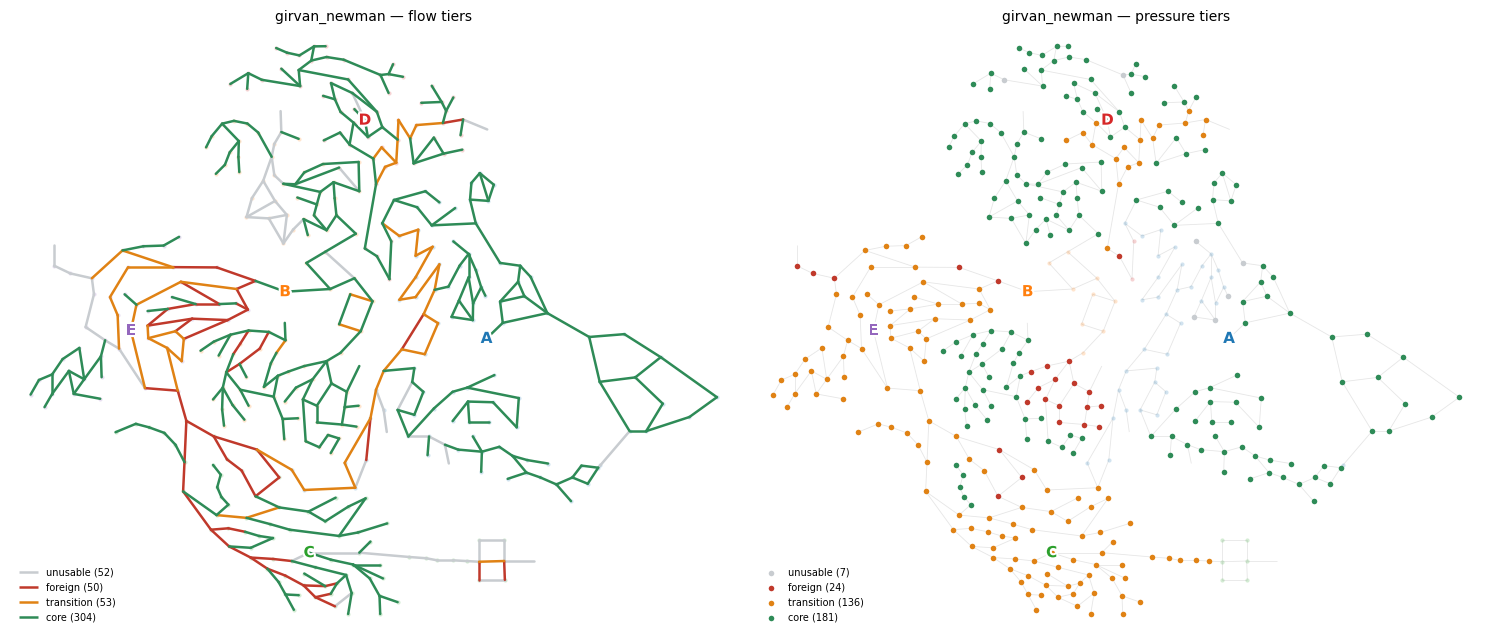

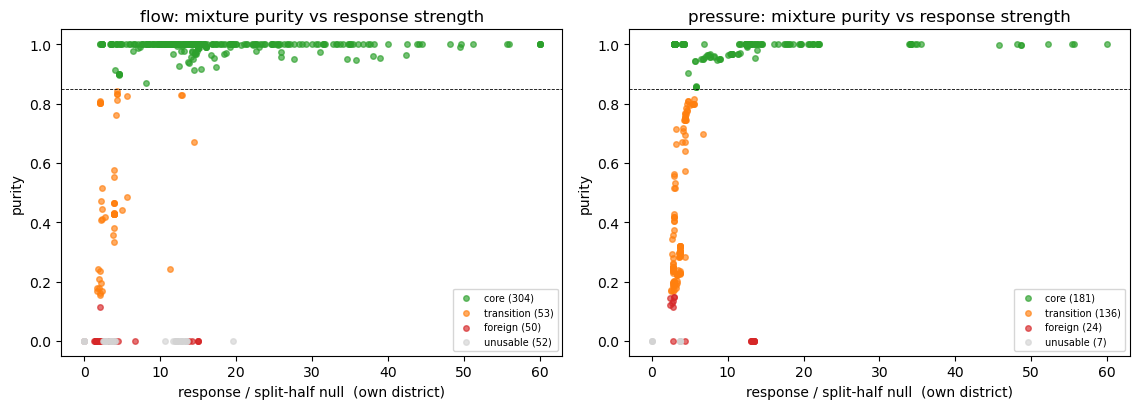

In [10]:
display(R0.connectivity)

TOPO = bd.topology(ROOT / "data" / "01_raw" / B0.network / "network.inp")
TAB0 = pl.classification(R0)
fig, ax = plt.subplots(1, 2, figsize=(15, 6.4))
F.tier_network(ax[0], TOPO, TAB0, R0.districts, "flow", title=f"{R0.method} — flow tiers")
F.tier_network(ax[1], TOPO, TAB0, R0.districts, "pressure",
               title=f"{R0.method} — pressure tiers")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.2))
for a, k in zip(ax, ("flow", "pressure")):
    mp.plot_purity({"mixture": R0.mixture, "districts": R0.names}, k, ax=a)
plt.tight_layout(); plt.show()

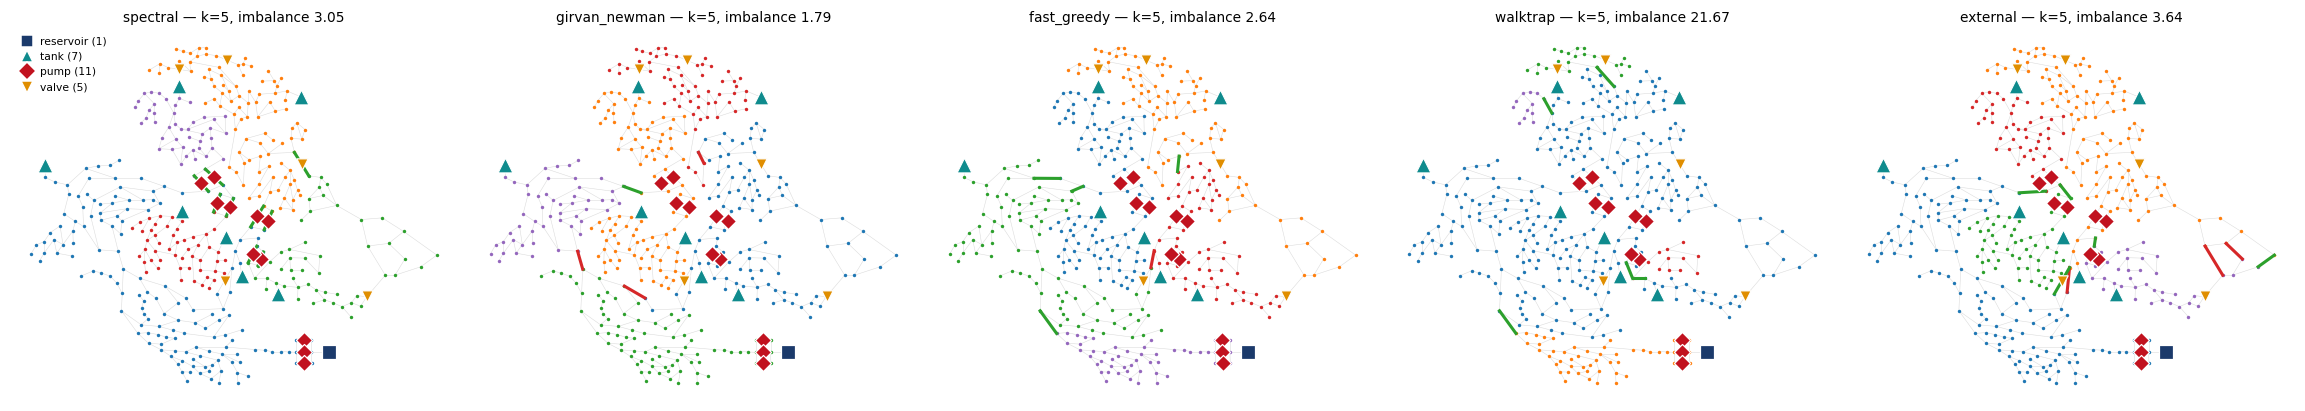

## 3. The sweep

Every partition, cached and resumable. A configuration that fails is recorded and the grid
continues — an infeasible partition is a result about that partition. Note that a
configuration needs *all* K worlds: the mixture stacks one per district, so a missing world
is a missing column, not a smaller sample.

In [11]:
RESULTS = ds.run(BUNDLES, CFG, ROOT, STORE, worlds_root=WORLDS)
SUMM = ds.summarise(RESULTS)
display(SUMM)


=== fast_greedy__65c3cb80 (fast_greedy) -- 5 worlds ===
  [1/5] dtown__fast_greedy__65c3cb80/District_A/beta=0.35  cache  dDemand  +116.8%  shift 0.73  flow gap 1.03  resp 1.00  2s  | eta 0 min
  [2/5] dtown__fast_greedy__65c3cb80/District_B/beta=0.35  cache  dDemand  +118.0%  shift 0.72  flow gap 0.96  resp 1.00  2s  | eta 0 min
  [3/5] dtown__fast_greedy__65c3cb80/District_C/beta=0.35  cache  dDemand  +116.8%  shift 0.73  flow gap 0.97  resp 1.00  1s  | eta 0 min
  [4/5] dtown__fast_greedy__65c3cb80/District_D/beta=0.35  cache  dDemand  +118.5%  shift 0.73  flow gap 0.87  resp 1.00  1s  | eta 0 min
  [5/5] dtown__fast_greedy__65c3cb80/District_E/beta=0.35  cache  dDemand  +118.1%  shift 0.72  flow gap 0.91  resp 1.00  1s  | eta 0 min

5/5 cells ok in 0.1 min -> c:\Users\arthu\USPy\10_Mestrado\fedWater\data\09_experiments\placement\worlds\fast_greedy__65c3cb80
  District_A: settled from month 18
  District_B: settled from month 18
  District_C: settled from month 14
  District_D: set

,config_id,method,status,seconds,cells_ok,cells,flow_offdiag,flow_offdiag_max,pressure_offdiag,pressure_offdiag_max,n_core,n_transition,n_foreign,n_unusable,min_coverage,error
0,fast_greedy__65c3cb80,fast_greedy,ok,12.5,5,5,0.0538,0.2143,0.1132,0.5804,496,145,95,71,1.0,
1,girvan_newman__3ad4da44,girvan_newman,ok,13.1,5,5,0.0889,0.3660,0.1985,0.8807,485,189,74,59,1.0,
2,spectral__01d6bf55,spectral,ok,12.6,5,5,0.0504,0.2402,0.0483,0.2891,469,188,97,53,1.0,


## 4. Summary across partitions

Per-gauge rows cannot be pooled across configurations — `home` is partition-dependent, so
the same element is a different observation under a different cut. The element *is* shared,
though, so keying on it answers the one cross-configuration question that is well posed:
which elements are readable whatever the cut.

In [12]:
EL = ds.elements(RESULTS)
display(EL.groupby(["method", "kind", "tier"]).size().unstack(fill_value=0))

robust = (EL[EL["tier"].isin(["core", "transition"])]
          .groupby(["element", "kind"])
          .agg(n_configs=("config_id", "nunique"),
               purity_mean=("purity", "mean"), purity_sd=("purity", "std"),
               swing=("purity_swing", "mean")).reset_index())
robust = robust[robust["n_configs"] == EL["config_id"].nunique()]
display(robust.sort_values("purity_sd").head(20).round(3))
print(f"{len(robust)} elements readable under every partition")

tier                    core  foreign  transition  unusable
method        kind                                         
fast_greedy   flow       310       81          26        42
              pressure   186       14         119        29
girvan_newman flow       304       50          53        52
              pressure   181       24         136         7
spectral      flow       278       77          59        45
              pressure   191       20         129         8

,element,kind,n_configs,purity_mean,purity_sd,swing
0,1,flow,3,1.0,0.0,0.000
420,P2,flow,3,1.0,0.0,0.333
416,P177,flow,3,1.0,0.0,0.000
415,P174,flow,3,1.0,0.0,0.006
410,P162,flow,3,1.0,0.0,0.001
409,P161,flow,3,1.0,0.0,0.000
408,P160,flow,3,1.0,0.0,0.000
405,P158,flow,3,1.0,0.0,0.000
404,P157,flow,3,1.0,0.0,0.000
403,P156,flow,3,1.0,0.0,0.000


617 elements readable under every partition


## 5. Interactive views

**Sweep browser** — the response/leak matrix beside the resemblance metric drawn on the
network. The slider keeps the top N gauges per district; the metric drives colour and size
together, so a district whose best gauges are faint and thin is one no placement recovers.

In [13]:
_ = B.sweep_browser(RESULTS, TOPO)

**Mixture browser** — one configuration: tiers on the network with district identity,
the per-district simplex, and the two matrices. `dependence R[j,k]` uses every gauge and no
threshold; `response` is the tier-restricted transpose.

In [14]:
_ = B.mixture_browser(RESULTS[B0.config_id], TOPO)

**Lab browser** — one world: weekly shapes, the selection map, and the shape-distance
clustering. The selection map's upper right is where a prototype comes from; a gauge with
high resemblance and response ≈ 0 is dominated by transit flow.

In [ ]:
P0 = R0.probes[sorted(R0.probes)[0]]
SC0 = R0.scores[R0.scores["sim_hash"] == P0.label.split(":")[-1]]
if not len(SC0):
    SC0 = R0.scores[R0.scores["drift_district"] == sorted(R0.probes)[0]]
_ = B.lab_browser(P0, SC0)

## 6. Sensor sets

Four arms per configuration, each a complete `sensors:` block of at most 5 per district per
kind. All four rank on **purity**: `r_res_own` would be a fine score for "resembles its own
district", but the target set is mixture-defined, so controls on another axis would not be
matched controls.

    control_high   tier core, purity → 1      reads almost only its own district
    control_low    tier foreign, purity → 0   responds strongly, to the WRONG district
    target         purity in [0.25, 0.75],    a quantified blend of two named districts
                   w_second ≥ 0.20, stable
    unusable       did not move for any drift — report only, never a pipeline arm

`control_low` is `foreign`, not `unusable`: a foreign gauge is a transit pipe whose flow
reverses when the local district draws more, so a client metered there is reading a
neighbour — an informative failure. An `unusable` client gets a flat series and the FL run
degenerates instead.

Short sets **ship ragged**. Padding to 5 from outside the criteria would put non-targets in
the target arm. The cost is real and is recorded rather than discovered later: client CSVs
then differ in column count per kind, and `preprocess_clients` reads that as a different
feature geometry per client — `coverage.csv` and `handoff.json:ragged` are what tell the FL
step so.

In [16]:
for cid, r in RESULTS.items():
    if r.status != "ok":
        print(f"{cid}: skipped ({r.status}) {r.error}"); continue
    print(f"# ---- {cid} ----")
    pl.emit(r, STORE, arms=pl.PIPELINE_ARMS, n_max=5)

COV = pd.concat([pd.read_csv(STORE / cid / "placements" / "coverage.csv")
                 for cid, r in RESULTS.items() if r.status == "ok"],
                ignore_index=True)
display(COV.groupby(["config_id", "arm", "kind"])
        .agg(gauges=("n_selected", "sum"), short=("complete", lambda x: (~x).sum()),
             empty=("empty", "sum")).reset_index())

# ---- fast_greedy__65c3cb80 ----
  control_high    45 gauges | 1/10 sets short | 1 empty
  control_low     31 gauges | 4/10 sets short | 3 empty
  target          11 gauges | 8/10 sets short | 7 empty
  unusable        31 gauges | 5/10 sets short | 2 empty
# ---- girvan_newman__3ad4da44 ----
  control_high    45 gauges | 1/10 sets short | 1 empty
  control_low     31 gauges | 5/10 sets short | 1 empty
  target          24 gauges | 7/10 sets short | 4 empty
  unusable        26 gauges | 6/10 sets short | 4 empty
# ---- spectral__01d6bf55 ----
  control_high    50 gauges | 0/10 sets short | 0 empty
  control_low     19 gauges | 7/10 sets short | 6 empty
  target          17 gauges | 8/10 sets short | 6 empty
  unusable        22 gauges | 7/10 sets short | 4 empty


,config_id,arm,kind,gauges,short,empty
0,fast_greedy__65c3cb80,control_high,flow,25,0,0
1,fast_greedy__65c3cb80,control_high,pressure,20,1,1
2,fast_greedy__65c3cb80,control_low,flow,21,1,0
3,fast_greedy__65c3cb80,control_low,pressure,10,3,3
4,fast_greedy__65c3cb80,target,flow,6,4,3
5,fast_greedy__65c3cb80,target,pressure,5,4,4
6,fast_greedy__65c3cb80,unusable,flow,17,2,0
7,fast_greedy__65c3cb80,unusable,pressure,14,3,2
8,girvan_newman__3ad4da44,control_high,flow,25,0,0
9,girvan_newman__3ad4da44,control_high,pressure,20,1,1


In [17]:
SEL = pd.concat([pd.read_parquet(STORE / cid / "placements" / "selection.parquet")
                 for cid, r in RESULTS.items() if r.status == "ok"],
                ignore_index=True)
cols = ["arm", "district", "kind", "rank", "id", "tier", "purity", "second",
        "w_second", "snr_home", "purity_swing", "r_res_own_init"]
display(SEL[(SEL["config_id"] == B0.config_id) & (SEL["arm"] == "target")][cols].round(3))

,arm,district,kind,rank,id,tier,purity,second,w_second,snr_home,purity_swing,r_res_own_init
194,target,District_A,flow,1,q_P237,transition,0.433,District_D,0.567,3.971,0.008,-0.001
195,target,District_A,flow,2,q_P379,transition,0.433,District_D,0.567,3.971,0.008,-0.001
196,target,District_A,flow,3,q_P238,transition,0.426,District_D,0.574,3.950,0.008,-0.000
197,target,District_A,flow,4,q_P292,transition,0.426,District_D,0.574,3.950,0.008,-0.000
198,target,District_A,flow,5,q_P934,transition,0.426,District_D,0.574,3.950,0.008,-0.000
199,target,District_C,pressure,1,p_J109,transition,0.282,District_D,0.293,3.621,0.048,-0.072
200,target,District_C,pressure,2,p_J101,transition,0.283,District_D,0.293,3.623,0.048,-0.072
201,target,District_C,pressure,3,p_J95,transition,0.296,District_D,0.302,3.664,0.050,-0.070
202,target,District_C,pressure,4,p_J110,transition,0.295,District_D,0.302,3.663,0.050,-0.070
203,target,District_C,pressure,5,p_J96,transition,0.297,District_D,0.301,3.665,0.050,-0.070


## 7. Do the selected sets make sense?

Two checks, on the arm that matters. Against the **demand profile**: a gauge chosen for its
mixture should still be recognisably reading water — a flat trace against a strongly shaped
demand week means the arm picked something the district's behaviour does not reach. Against
**location**: a target gauge should sit where two districts meet, and a `control_high`
gauge should sit inside its own.

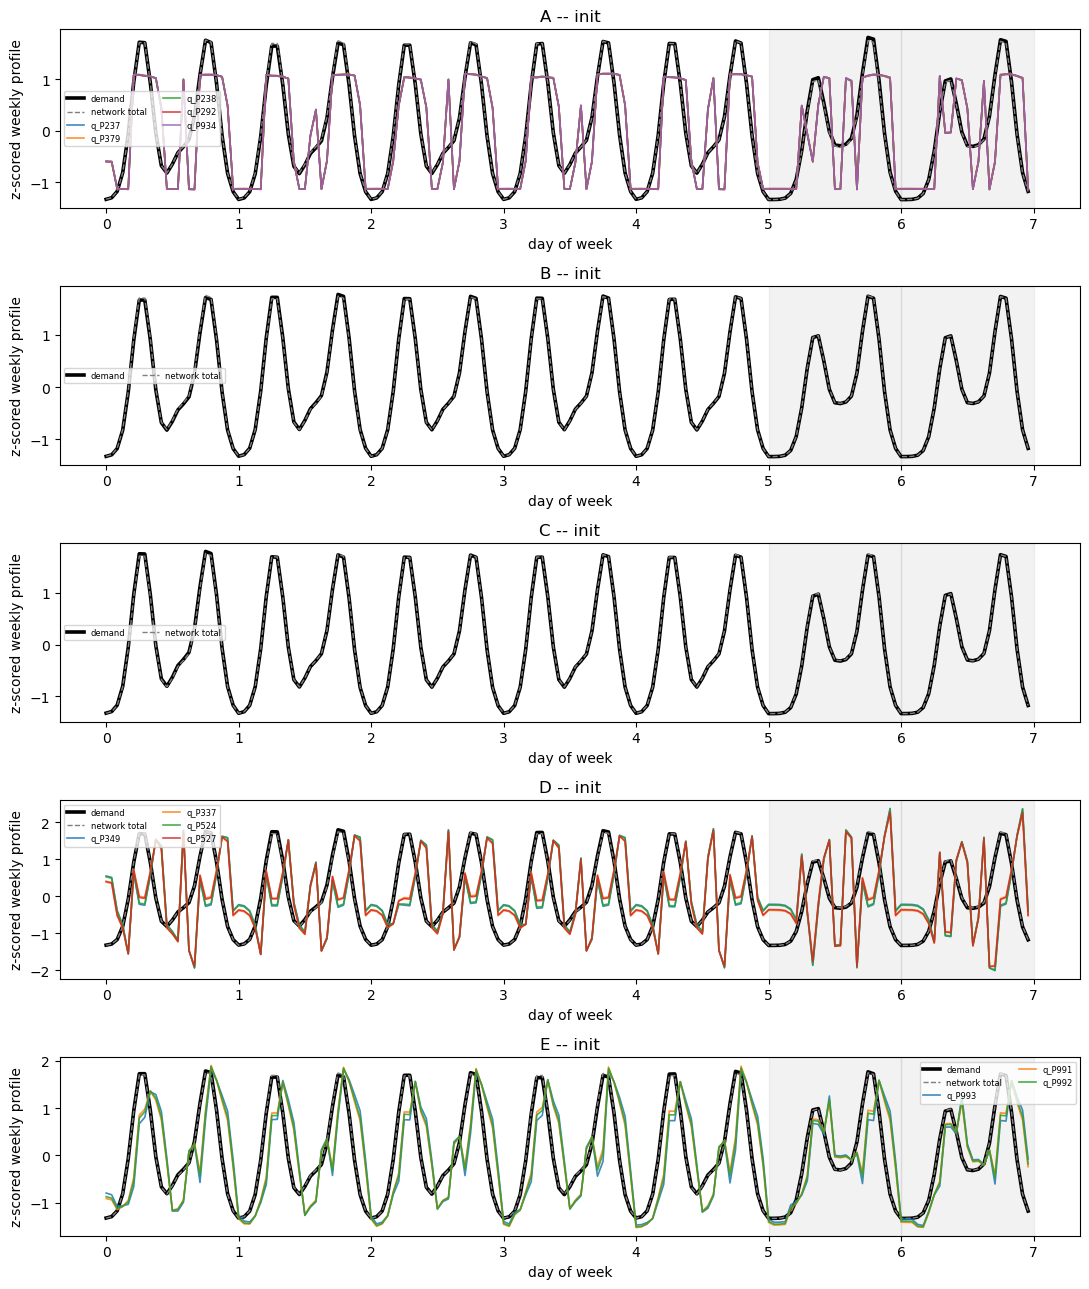

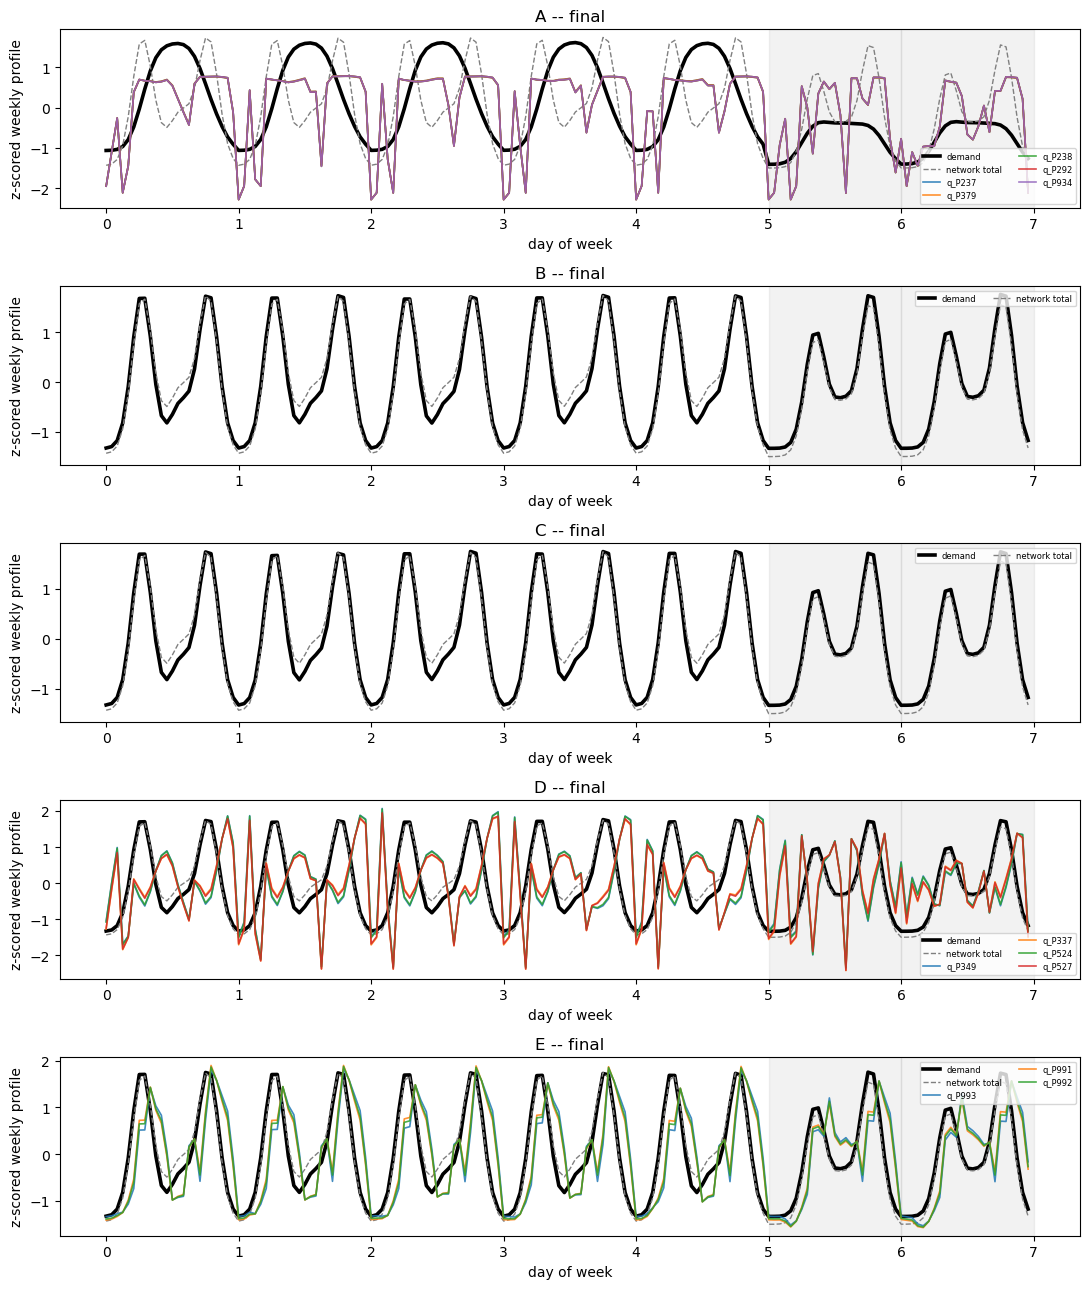

In [22]:
S0 = SEL[SEL["config_id"] == B0.config_id]
KIND = "flow"
fig, axes = plt.subplots(len(R0.names), 1, figsize=(11, 2.6 * len(R0.names)),
                         squeeze=False)
for ax, d in zip(axes[:, 0], R0.names):
    ids = list(S0[(S0["arm"] == "target") & (S0["district"] == d)
                  & (S0["kind"] == KIND)]["id"])
    F.selection_vs_demand(ax, P0, ids, d, phase="init")
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(len(R0.names), 1, figsize=(11, 2.6 * len(R0.names)),
                         squeeze=False)
for ax, d in zip(axes[:, 0], R0.names):
    ids = list(S0[(S0["arm"] == "target") & (S0["district"] == d)
                  & (S0["kind"] == KIND)]["id"])
    F.selection_vs_demand(ax, P0, ids, d, phase="final")
plt.tight_layout(); plt.show()

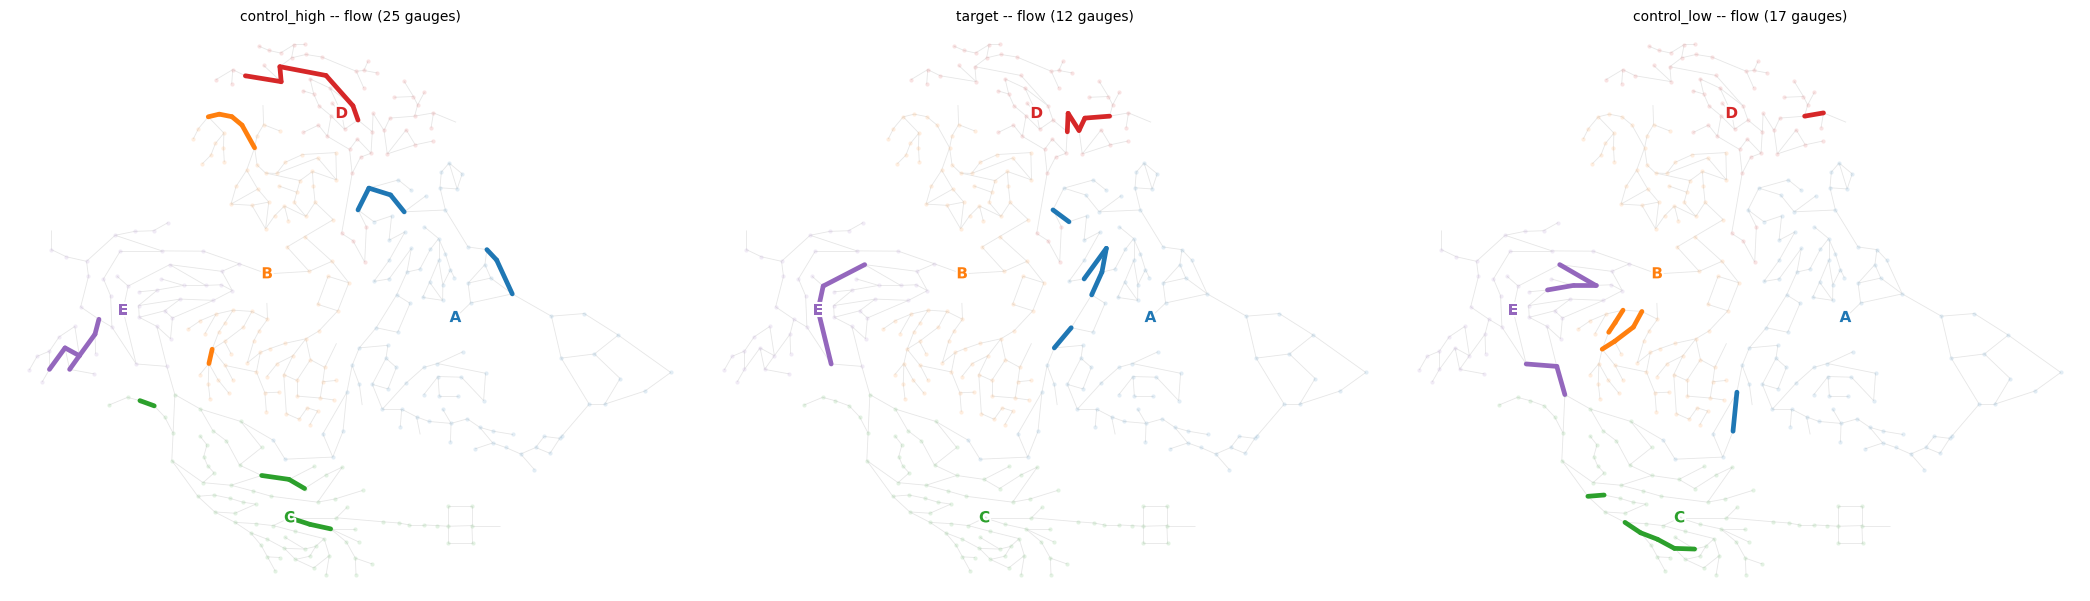

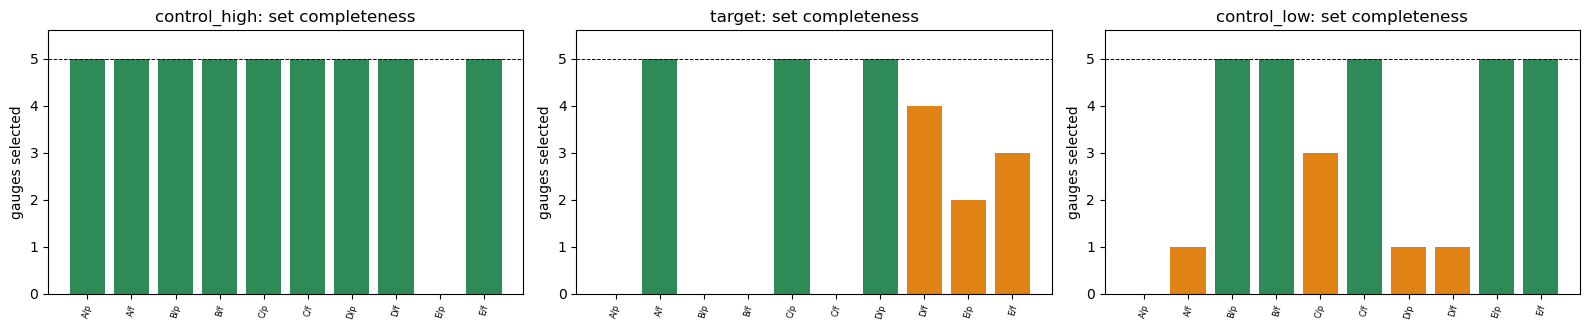

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6.6))
for ax, arm in zip(axes, ("control_high", "target", "control_low")):
    F.selection_network(ax, TOPO, S0, R0.districts, arm, KIND)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 3.4))
for ax, arm in zip(axes, ("control_high", "target", "control_low")):
    F.coverage_bars(ax, COV[COV["config_id"] == B0.config_id], arm)
plt.tight_layout(); plt.show()

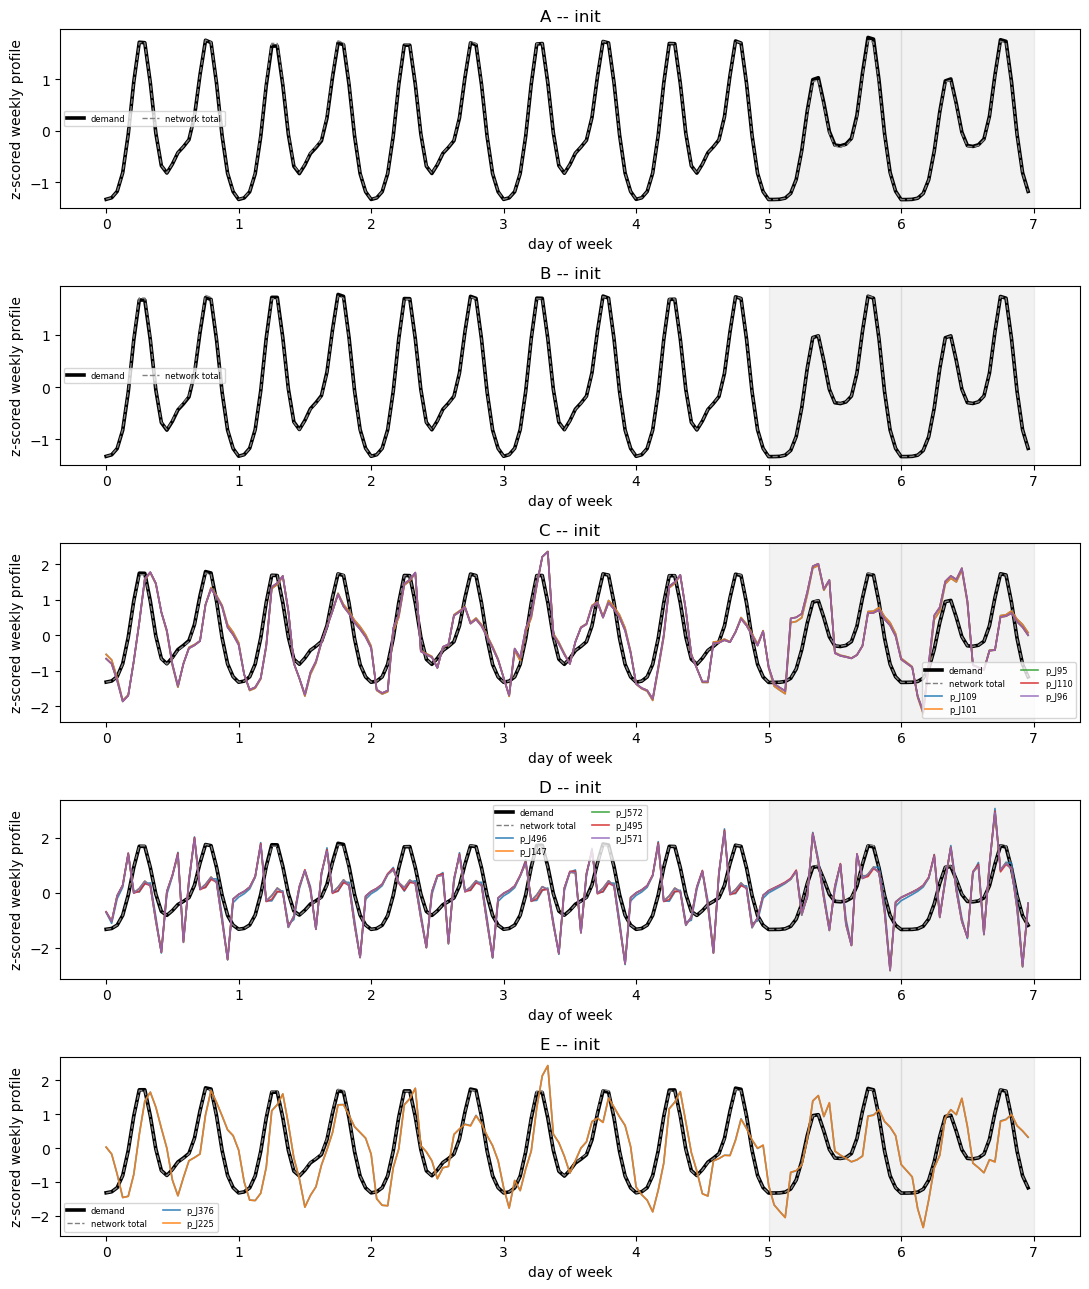

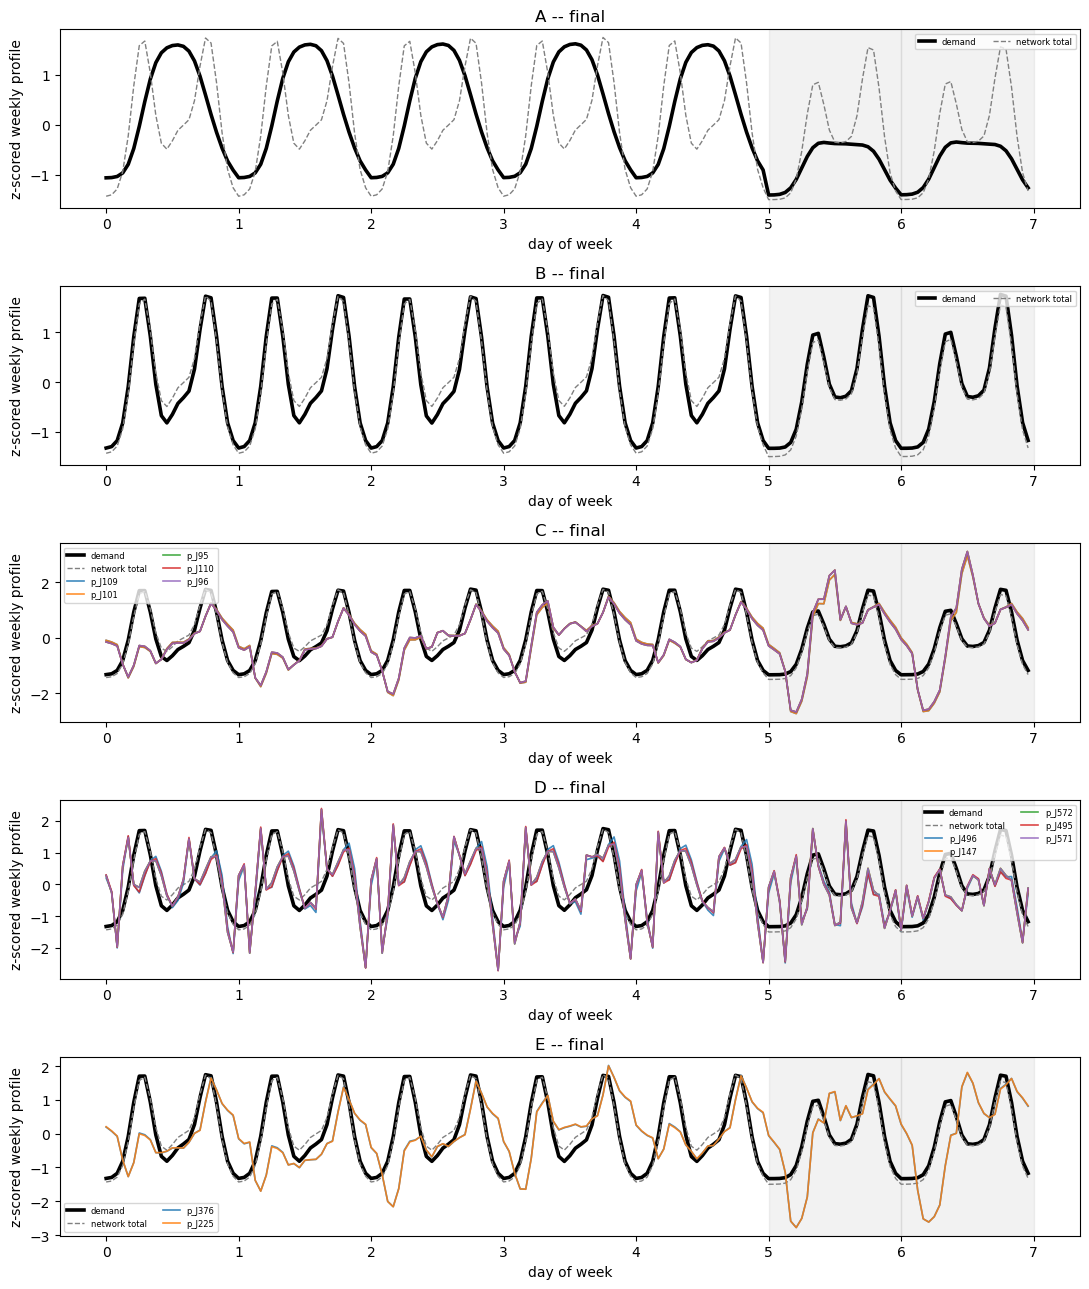

In [24]:
S0 = SEL[SEL["config_id"] == B0.config_id]
KIND = "pressure"
fig, axes = plt.subplots(len(R0.names), 1, figsize=(11, 2.6 * len(R0.names)),
                         squeeze=False)
for ax, d in zip(axes[:, 0], R0.names):
    ids = list(S0[(S0["arm"] == "target") & (S0["district"] == d)
                  & (S0["kind"] == KIND)]["id"])
    F.selection_vs_demand(ax, P0, ids, d, phase="init")
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(len(R0.names), 1, figsize=(11, 2.6 * len(R0.names)),
                         squeeze=False)
for ax, d in zip(axes[:, 0], R0.names):
    ids = list(S0[(S0["arm"] == "target") & (S0["district"] == d)
                  & (S0["kind"] == KIND)]["id"])
    F.selection_vs_demand(ax, P0, ids, d, phase="final")
plt.tight_layout(); plt.show()

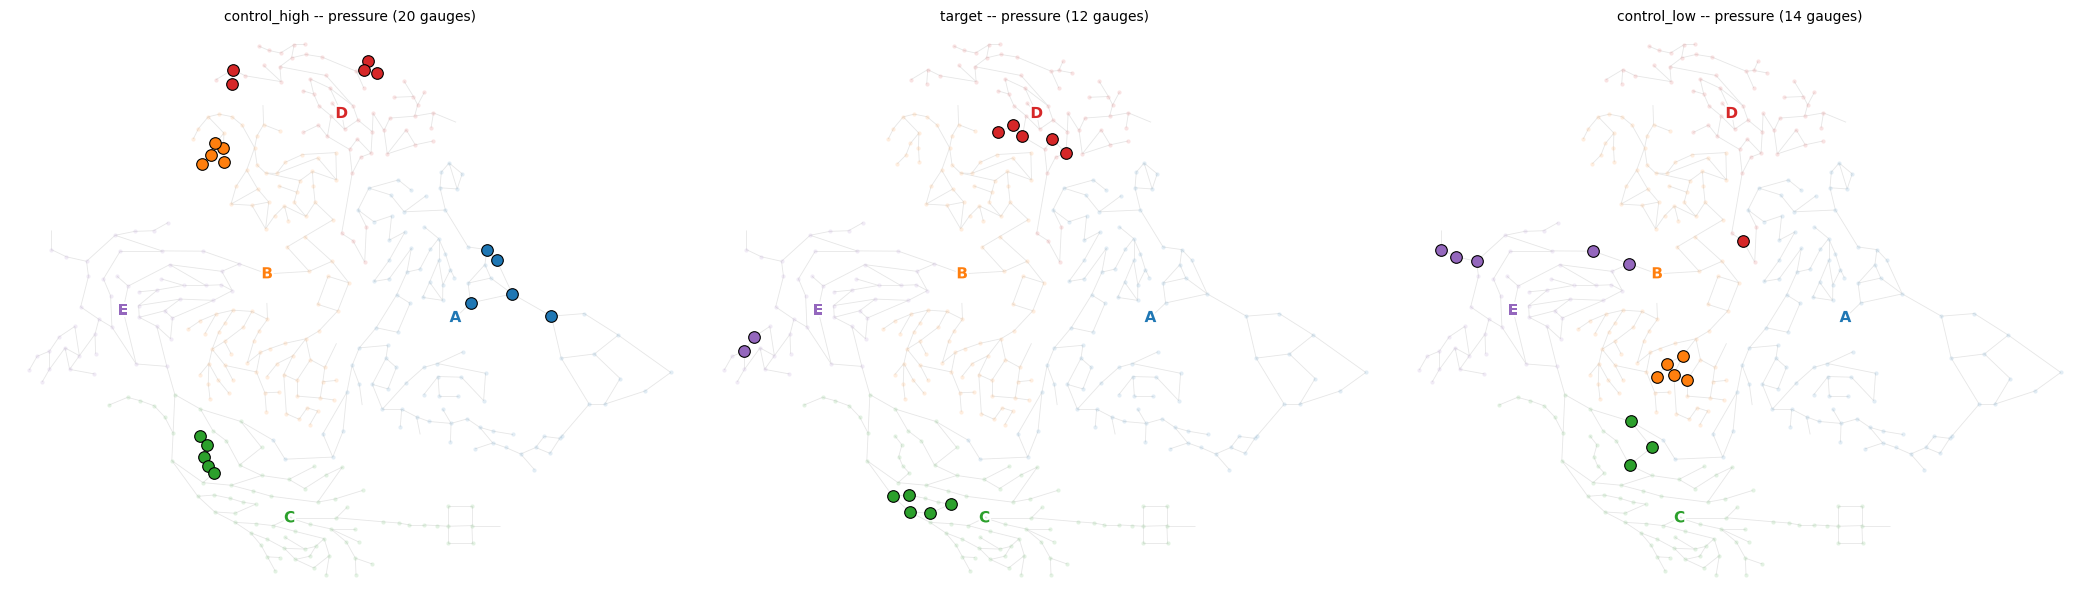

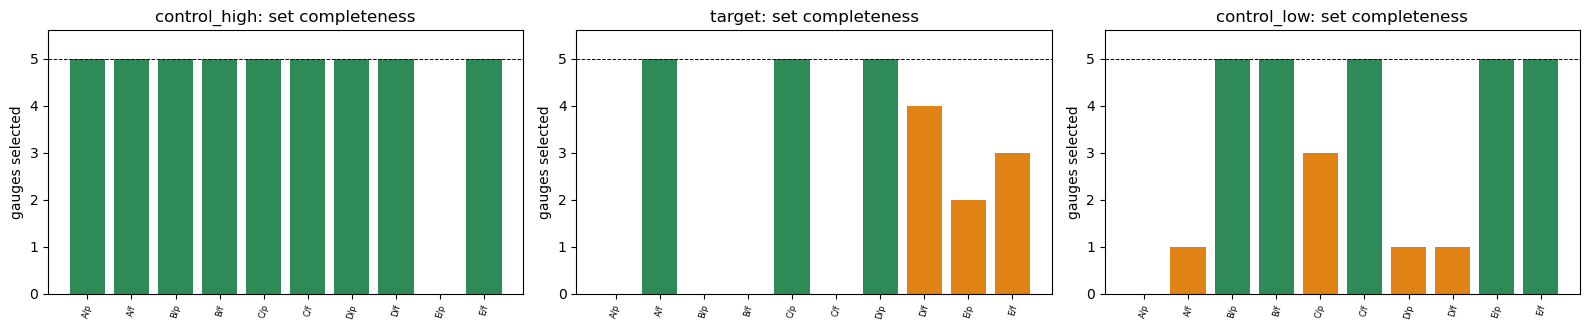

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6.6))
for ax, arm in zip(axes, ("control_high", "target", "control_low")):
    F.selection_network(ax, TOPO, S0, R0.districts, arm, KIND)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 3.4))
for ax, arm in zip(axes, ("control_high", "target", "control_low")):
    F.coverage_bars(ax, COV[COV["config_id"] == B0.config_id], arm)
plt.tight_layout(); plt.show()

In [20]:
# The arms, scored on the axis they were NOT chosen on. control_high should sit high in
# r_res_own and control_low low; if they do not, purity and resemblance are measuring
# different things on this network and that is worth knowing before FL runs.
display(SEL.groupby(["method", "arm", "kind"])
        [["purity", "w_second", "snr_home", "r_res_own_init", "response_mean"]]
        .mean().round(3))

KeyError: 'method'

## 8. Read-out

**(a) Is the dependence real, or is it the threshold?** §2c. If `n_live<=1_%` is high and
the tier counts move across `null_factor`, the mixture is one-hot by construction and the
target arm has nothing to select from. If the purity histogram has mass between 0.25 and
0.75 that survives the sweep, there is a readable blend and §6's target set is a measured
object.

**(b) Which partition to carry forward.** `configs.csv`. The partition to prefer is the one
with the largest diagonal-to-off-diagonal ratio in `R[j,k]` *and* a non-empty target set —
a cleanly separated partition with no quantified mixtures gives FL no dependence to
recover, and a heavily mixed one gives it no clean client. Both numbers, not either.

**(c) Pressure.** If the pressure `R` off-diagonal sits near its diagonal, a pressure gauge
cannot attribute a drift to a district even when it detects one, and pressure channels
should be dropped from the FL feature set rather than carried as noise. The Graeme
discriminative gap (0.004 pressure against 0.234 flow) says to expect this.

**(d) What is NOT claimed.** One beta, so no linearity check: these numbers hold at this
operating point. Influence, not causality. And the honest sample size is the number of
partitions, not the number of gauges.

### Next
`handoff.json` per configuration names `districts.yml` and one yml per arm. That tuple is
the federated step's input. Run the arms as matched conditions: if FL recovers dependence
on `target` and not on `control_high`, the recovery is the mixture and not the pipeline.